#### Полный алгоритм: <br>
0) Предлагаю сделать по 100 картинок размера 28 на 28 каждой цифры (в итоге 1000 изображений)
1) Нарисовать 100 штук одной цифры в Paint (белой кистью на чёрном фоне), сложить всё в одну папку, подписать и пронумеровать
2) Через код пройтись по папке по каждому изображению. Перевести в чб, нормализовать, решейпить, **добавить нулевым индексом число, которое изображено на картинке**, добавить в общий двойной массив
3) сохранить получившийся массив в файл.
4) загрузить из файла в другой массив уже в коде, где нам это требуется, и в конечном счёте расширить датасет MNIST нашими рукописными картинками **(но нужно будет грамотно обработать нулевые индексы, где у нас лежит таргетная переменная так сказать)**.
Можно тоже через vstack добавить вниз исходного массива наши 1000 картинок, и то же самое для таргетов: просто вниз добавить 1000 строк, у которых единицы будут у первых 100 картинок на 0 индексе, у следующих - на первом и так далее. но тогда важно сохранить порядок картинок. иначе если рассинхрон между нашими картинками и тем, как массивы в таргете лежат, то всё поломается.

In [18]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

### Конвертация png-изображения в np.array размера [1,785]

In [ ]:
def print_img(np_array):
    plt.imshow(np_array, cmap = "gray")
    plt.show()

In [ ]:
for root, dirs, files in os.walk('Full path to a folder with your digits'):
    all_zeros = []
    for file in files:
        with Image.open("Dataset MNIST/"+file) as img:
            img = img.convert('L')
            img_array = np.array(img)
            img_array = img_array / 255
            img_array = np.reshape(img_array, (1, 784))
            img_array = np.insert(img_array, 0, 0) # 785 values
            all_zeros.append(img_array)
            print(file + 'finished')
    all_zeros = np.array(all_zeros)
    np.save('100 handwritten zeros', all_zeros)

### Загрузка массива и визуализация содержимого

In [35]:
loaded_arr = np.load('100 handwritten zeros.npy') # тут получили массив нулей

# ниже пример объединения разных цифр в один общий удобный массив general, который потом объединим с исходным MNIST
# clear_zeros = loaded_arr[:, 1:]
# np_ones = np.ones((100, 784))
# general = np.vstack((clear_zeros, np_ones))
# general.shape

(200, 784)

In [28]:
loaded_arr.shape

(100, 785)

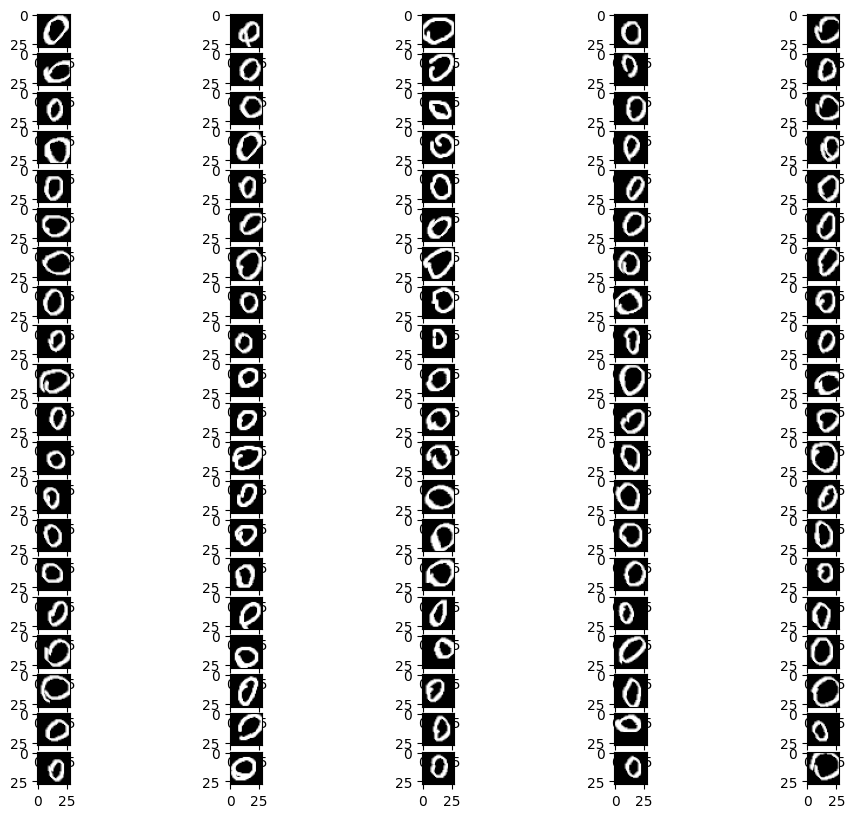

In [27]:
fig, ax = plt.subplots(20, 5, figsize=(12, 10))
for i in range(20):
  for j in range(5):
    number = j*20 + i
    img = loaded_arr[number][1:]
    img = np.reshape(img, (28, 28))
    ax[i][j].imshow(img, cmap="gray")
plt.show()